## Configuración inicial e identidad visual

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo general
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 2. Paleta de colores corporativa
# PALETA_FUGA: gris para empleados que se quedan (0), rojo para los que se van (1)
PALETA_CORPORATIVA = ["#4A90E2", "#7B8A98", "#E056FD", "#2ECC71"]
PALETA_FUGA = {0: "#7B8A98", 1: "#FF6B6B"}

# 3. Carga del CSV limpio generado en la Fase 2
df_eda = pd.read_csv('../Fase2/Fase2_ParejaB_limpiezaJezi.csv')

print("📊 Entorno de visualización configurado.")
print(f"Dataset cargado: {df_eda.shape[0]} filas y {df_eda.shape[1]} columnas")

📊 Entorno de visualización configurado.
Dataset cargado: 1470 filas y 32 columnas


## Pregunta 1 — ¿Por qué se van los empleados?
### Attrition por años en la empresa (YearsAtCompany)

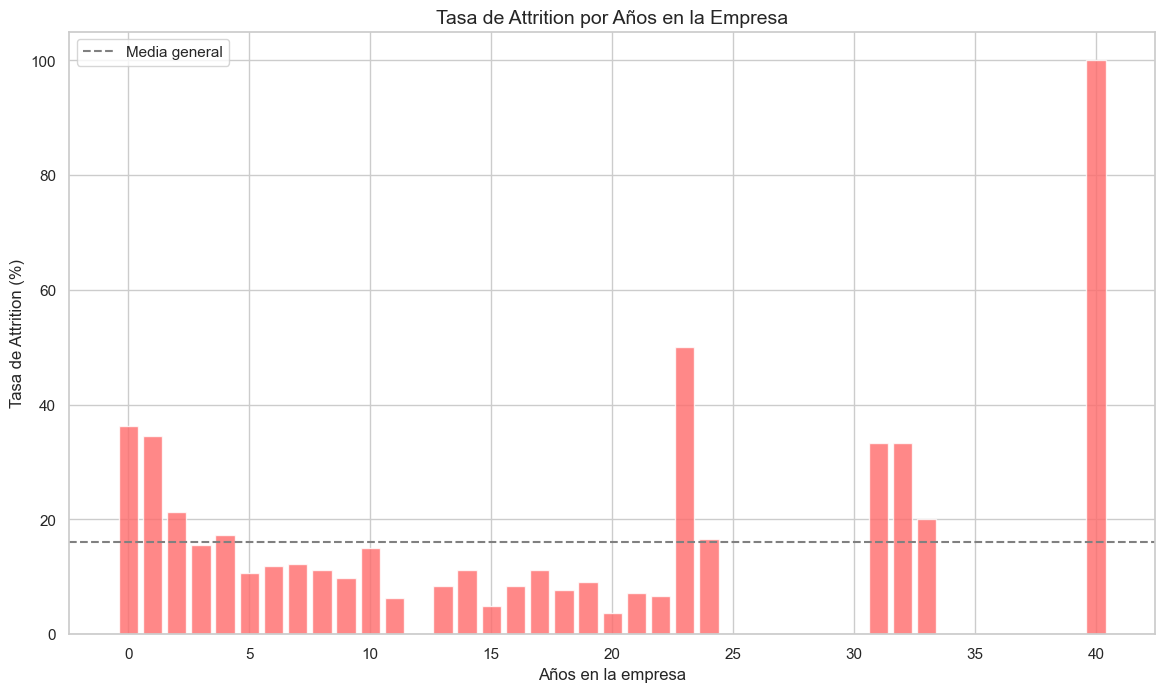

In [24]:
# Definimos el factor de conversión de centímetros a pulgadas
cm = 1 / 2.54

# Creamos el lienzo del gráfico con tamaño en centímetros convertidos a pulgadas
fig, ax = plt.subplots(figsize=(30*cm, 18*cm))

# Agrupamos el dataframe por años en la empresa
# y calculamos la media de Attrition (que al ser 0/1 nos da directamente el porcentaje)
attrition_years = df_eda.groupby('YearsAtCompany')['Attrition'].mean() * 100

# Dibujamos las barras: eje X = años en empresa, eje Y = tasa de fuga en %
ax.bar(attrition_years.index, attrition_years.values, color=PALETA_FUGA[1], alpha=0.8)

# Ponemos título y etiquetas a los ejes
ax.set_title('Tasa de Attrition por Años en la Empresa')
ax.set_xlabel('Años en la empresa')
ax.set_ylabel('Tasa de Attrition (%)')

# Añadimos una línea horizontal con la media general de Attrition
# para poder comparar cada barra contra el promedio global
ax.axhline(y=df_eda['Attrition'].mean() * 100, color='gray',
           linestyle='--', linewidth=1.5, label='Media general')

# Mostramos la leyenda
ax.legend()

# Ajustamos el espaciado para que no se solapen los elementos
plt.tight_layout()

# Mostramos el gráfico
plt.show()

**Conclusión — Attrition por años en la empresa**

La línea discontinua representa la media general de fuga (~16%). Vemos tres patrones claros:

- **Los primeros años (0-2) son los más críticos:** La tasa de fuga supera el 35%, casi el doble de la media. Los empleados recién incorporados son los más propensos a irse.
- **A partir del año 5 la situación se estabiliza:** La mayoría de barras cae por debajo de la media, lo que indica que quien supera los primeros años tiende a quedarse.
- **Los picos en años 23 y 40 son anomalías estadísticas:** Hay muy pocos empleados con esa antigüedad, por lo que un solo caso que se vaya dispara el porcentaje. No son tendencias reales.

**Recomendación:** ABC Corporation debe centrar sus esfuerzos de retención en los **primeros 2 años** de vida del empleado en la empresa, que es cuando el riesgo de fuga es máximo.

## Pregunta 1 — ¿Por qué se van los empleados?
### Attrition por nivel de puesto (JobLevel)

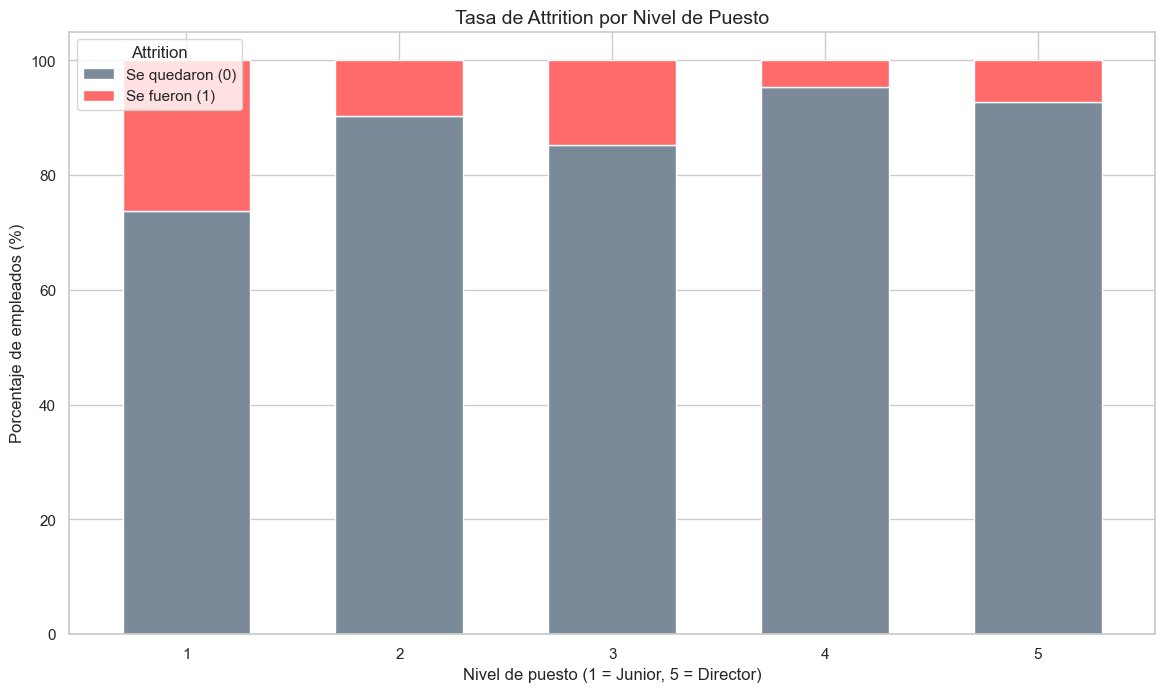

In [25]:
# Definimos el factor de conversión de centímetros a pulgadas
cm = 1 / 2.54

# Creamos el lienzo del gráfico
fig, ax = plt.subplots(figsize=(30*cm, 18*cm))

# Calculamos el número de empleados que se fueron y que se quedaron por nivel de puesto
# Usamos unstack() para separar los valores de Attrition en columnas (0 y 1)
attrition_joblevel = df_eda.groupby('JobLevel')['Attrition'].value_counts(normalize=True).unstack() * 100

# Dibujamos las barras apiladas con la paleta de colores corporativa
# 0 = se quedaron (gris), 1 = se fueron (rojo)
attrition_joblevel.plot(
    kind='bar',           # Tipo de gráfico: barras
    stacked=True,         # Barras apiladas para ver proporciones
    color=[PALETA_FUGA[0], PALETA_FUGA[1]],  # Colores: gris y rojo
    ax=ax,                # Usamos el eje que creamos antes
    edgecolor='white',    # Borde blanco entre barras para mayor claridad
    width=0.6             # Anchura de las barras
)

# Ponemos título y etiquetas a los ejes
ax.set_title('Tasa de Attrition por Nivel de Puesto')
ax.set_xlabel('Nivel de puesto (1 = Junior, 5 = Director)')
ax.set_ylabel('Porcentaje de empleados (%)')

# Rotamos las etiquetas del eje X para que sean legibles
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Actualizamos la leyenda con nombres más claros
ax.legend(['Se quedaron (0)', 'Se fueron (1)'], title='Attrition')

# Ajustamos el espaciado
plt.tight_layout()

# Mostramos el gráfico
plt.show()

**Conclusión — Attrition por nivel de puesto**

El gráfico muestra una tendencia muy clara: **cuanto más bajo es el nivel de puesto, mayor es la fuga.**

- **Nivel 1 (Junior):** Es el más crítico con aproximadamente un 26% de fuga. Casi 1 de cada 4 empleados junior abandona la empresa.
- **Niveles 2 y 3 (Medio):** La fuga se reduce pero sigue siendo notable, alrededor del 10-15%.
- **Niveles 4 y 5 (Senior y Director):** La fuga es mínima, por debajo del 5-8%. Los empleados más senior están claramente más consolidados.

**Recomendación:** Los puestos de nivel 1 necesitan atención urgente. Planes de carrera claros, mentoring y revisiones salariales tempranas pueden reducir significativamente la fuga en este tramo.

## Pregunta 2 — ¿Influye el sueldo?
### Distribución general de salarios (MonthlyIncome vs Attrition)

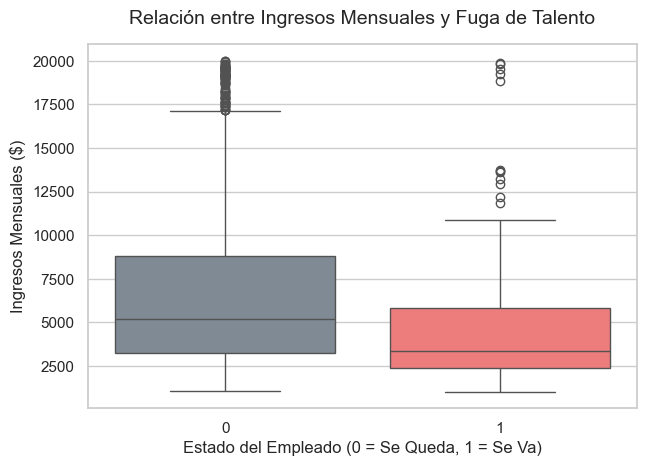

In [18]:
# 1. Limpieza y preparación de datos:
# Creamos una copia temporal del DataFrame eliminando registros que tengan nulos en la columna 'Attrition'.
# Esto nos permite aislar los datos necesarios sin alterar el DataFrame principal (df_eda).
df_grafico_boxplot = df_eda.dropna(subset=['Attrition']).copy()

# Convertimos explícitamente la columna 'Attrition' a tipo de dato entero puro (int).
# Es un paso crítico para corregir el 'ValueError'; así Seaborn puede emparejar los valores
# con las claves numéricas (0 y 1) de nuestro diccionario PALETA_FUGA.
df_grafico_boxplot['Attrition'] = df_grafico_boxplot['Attrition'].astype(int)

# 2. Conversión de unidades de medida:
# Definimos la constante matemática para transformar las pulgadas nativas de Matplotlib a centímetros (1 pulgada = 2.54 cm).
cm = 1 / 2.54

# 3. Inicialización del lienzo del gráfico:
# Diseñamos las dimensiones del lienzo con una proporción equilibrada para un boxplot: 18 cm de ancho por 12 cm de alto.
fig, ax = plt.subplots(figsize=(18 * cm, 12 * cm))

# 4. Construcción del diagrama de caja (Boxplot):
# Dibujamos el boxplot cruzando la variable categórica 'Attrition' (eje X) con la numérica 'MonthlyIncome' (eje Y).
# Nota técnica: Pasamos de manera explícita 'hue='Attrition'' y 'legend=False'. Esto soluciona por completo el
# 'FutureWarning' de las versiones modernas de Seaborn, manteniendo la aplicación de nuestra paleta de colores.
sns.boxplot(
    data=df_grafico_boxplot, 
    x='Attrition', 
    y='MonthlyIncome', 
    hue='Attrition', 
    palette=PALETA_FUGA, 
    legend=False, 
    ax=ax
)

# 5. Personalización estética y etiquetas del gráfico:
# Asignamos un título claro en la zona superior y le añadimos una separación (pad) con respecto al gráfico.
ax.set_title('Relación entre Ingresos Mensuales y Fuga de Talento', pad=15)

# Limpiamos los textos de los ejes X e Y añadiendo descripciones comprensibles para negocio y el símbolo monetario ($).
ax.set_xlabel('Estado del Empleado (0 = Se Queda, 1 = Se Va)')
ax.set_ylabel('Ingresos Mensuales ($)')

# 6. Renderizado:
# Solicitamos a la librería compilar y mostrar la gráfica de forma limpia y estilizada en la interfaz.
plt.show()

**Conclusión — Distribución de salarios según Attrition**

El boxplot muestra una diferencia salarial muy clara entre los dos grupos:

- **Los empleados que se fueron (rojo)** tienen una mediana salarial de aproximadamente **$3.500**, con la caja concentrada en los salarios más bajos.
- **Los empleados que se quedaron (gris)** tienen una mediana de aproximadamente **$5.000**, con una distribución más amplia hacia salarios altos.
- La caja roja es más estrecha y baja, lo que significa que la fuga se concentra casi exclusivamente en los tramos salariales más bajos.

**Recomendación:** Existe una brecha salarial directamente vinculada a la fuga. Revisar el suelo salarial de las posiciones operativas y acercarlo progresivamente a los **$4.500 - $5.000** reduciría significativamente el riesgo de perder talento por motivos económicos.

## Pregunta 3 — ¿Influye la edad en la fuga de talento?
### Distribución de edad: empleados que se fueron vs los que se quedaron

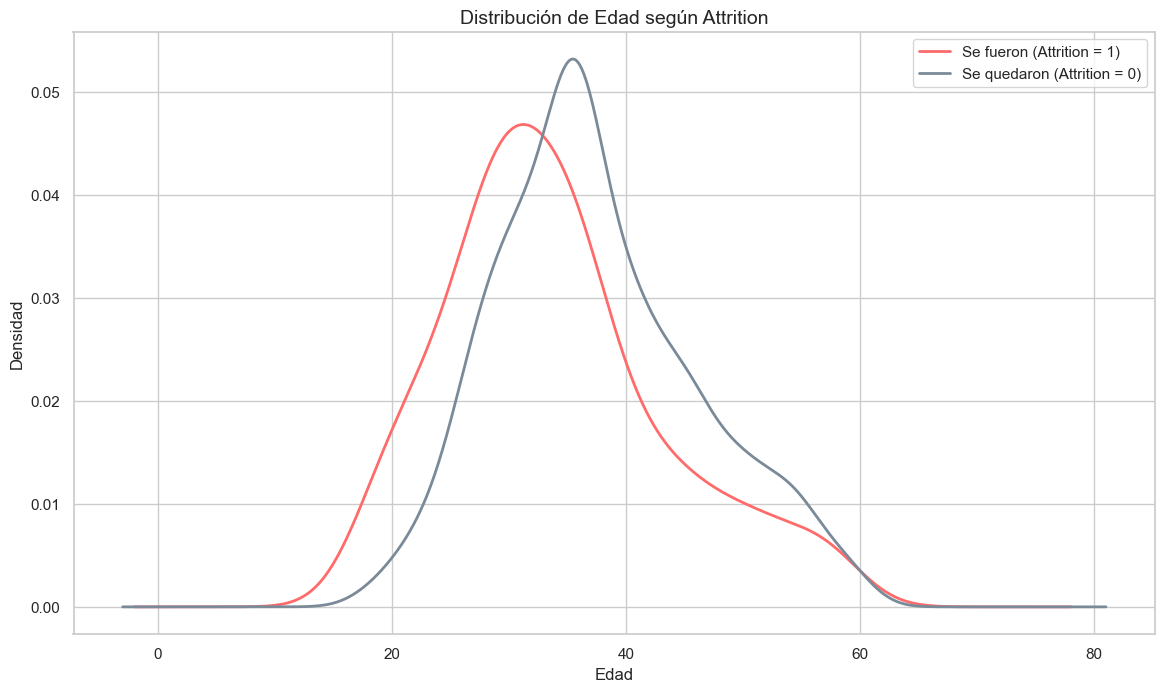

In [23]:
cm = 1 / 2.54

fig, ax = plt.subplots(figsize=(30*cm, 18*cm))

# Separamos los dos grupos
se_fueron = df_eda[df_eda['Attrition'] == 1]['Age']
se_quedaron = df_eda[df_eda['Attrition'] == 0]['Age']

# Dibujamos la densidad de cada grupo
se_fueron.plot.kde(ax=ax, color=PALETA_FUGA[1], linewidth=2, label='Se fueron (Attrition = 1)')
se_quedaron.plot.kde(ax=ax, color=PALETA_FUGA[0], linewidth=2, label='Se quedaron (Attrition = 0)')

ax.set_title('Distribución de Edad según Attrition')
ax.set_xlabel('Edad')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión — Distribución de edad según Attrition**

La curva roja (empleados que se fueron) está desplazada hacia la izquierda respecto a la gris (los que se quedaron). Esto significa que **los empleados más jóvenes, entre 20 y 35 años, tienen una mayor tendencia a abandonar la empresa**. A partir de los 40 años la fuga disminuye considerablemente, lo que sugiere que los empleados más senior están más consolidados en su posición.

**Recomendación:** ABC Corporation debería diseñar planes de carrera y retención específicos para el tramo de edad 20-35 años, que es donde se concentra el mayor riesgo de fuga.

## Pregunta 4 — ¿Influye la distancia al trabajo?
### Attrition según distancia al trabajo (DistanceFromHome)

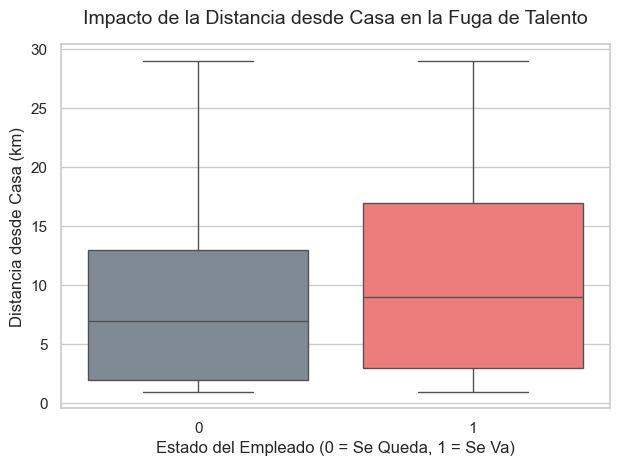

In [19]:
# 1. Limpieza y preparación de datos:
# Creamos una copia temporal del DataFrame eliminando registros nulos en las columnas implicadas.
# Así aseguramos la estabilidad del script antes de transformar los tipos de datos.
df_grafico_dist = df_eda.dropna(subset=['Attrition', 'DistanceFromHome']).copy()

# Convertimos la columna 'Attrition' a tipo de dato entero puro (int).
# Esto evita conflictos con Seaborn al mapear los colores de nuestro diccionario PALETA_FUGA.
df_grafico_dist['Attrition'] = df_grafico_dist['Attrition'].astype(int)

# 2. Conversión de unidades de medida:
# Definimos la constante matemática para transformar las pulgadas nativas de Matplotlib a centímetros (1 pulgada = 2.54 cm).
cm = 1 / 2.54

# 3. Inicialización del lienzo del gráfico:
# Diseñamos las dimensiones del lienzo con una proporción óptima para un boxplot: 18 cm de ancho por 12 cm de alto.
fig, ax = plt.subplots(figsize=(18 * cm, 12 * cm))

# 4. Construcción del diagrama de caja (Boxplot):
# Dibujamos el boxplot cruzando la variable categórica 'Attrition' (eje X) con la numérica 'DistanceFromHome' (eje Y).
# Nota técnica: Pasamos explícitamente 'hue='Attrition'' y 'legend=False' para corregir el 'FutureWarning' 
# de las versiones modernas de Seaborn, manteniendo la aplicación automática de nuestros colores.
sns.boxplot(
    data=df_grafico_dist, 
    x='Attrition', 
    y='DistanceFromHome', 
    hue='Attrition', 
    palette=PALETA_FUGA, 
    legend=False, 
    ax=ax
)

# 5. Personalización estética y etiquetas del gráfico:
# Asignamos un título representativo en la zona superior y le añadimos una separación (pad) con respecto al gráfico.
ax.set_title('Impacto de la Distancia desde Casa en la Fuga de Talento', pad=15)

# Limpiamos los textos de los ejes X e Y añadiendo descripciones comprensibles para la lectura del negocio.
ax.set_xlabel('Estado del Empleado (0 = Se Queda, 1 = Se Va)')
ax.set_ylabel('Distancia desde Casa (km)')

# 6. Renderizado:
# Solicitamos a la librería compilar y mostrar la gráfica final de forma limpia en la pantalla.
plt.show()

**Conclusión — Attrition según distancia al trabajo**

El boxplot revela que la distancia al centro de trabajo es un factor de desgaste acumulativo:

- **Los empleados que se quedaron (gris)** tienen una mediana de distancia de aproximadamente **7 km**, con el 75% viviendo a menos de **13 km** del trabajo.
- **Los empleados que se fueron (rojo)** tienen una mediana más alta y su distribución se estira significativamente, con muchos casos por encima de los **17 km**.
- La caja roja es más alta y tiene más valores atípicos en la parte superior, lo que confirma que a mayor distancia, mayor riesgo de fuga.

**Recomendación:** Implementar políticas de teletrabajo o jornada híbrida orientadas específicamente a empleados cuya distancia al centro de trabajo supere los **13 km**. Este umbral es el punto donde el riesgo de fuga empieza a dispararse.

## Pregunta 5 — ¿Qué hace que un empleado esté cómodo?
### Conciliación y horas extra vs Attrition (WorkLifeBalance + OverTime)

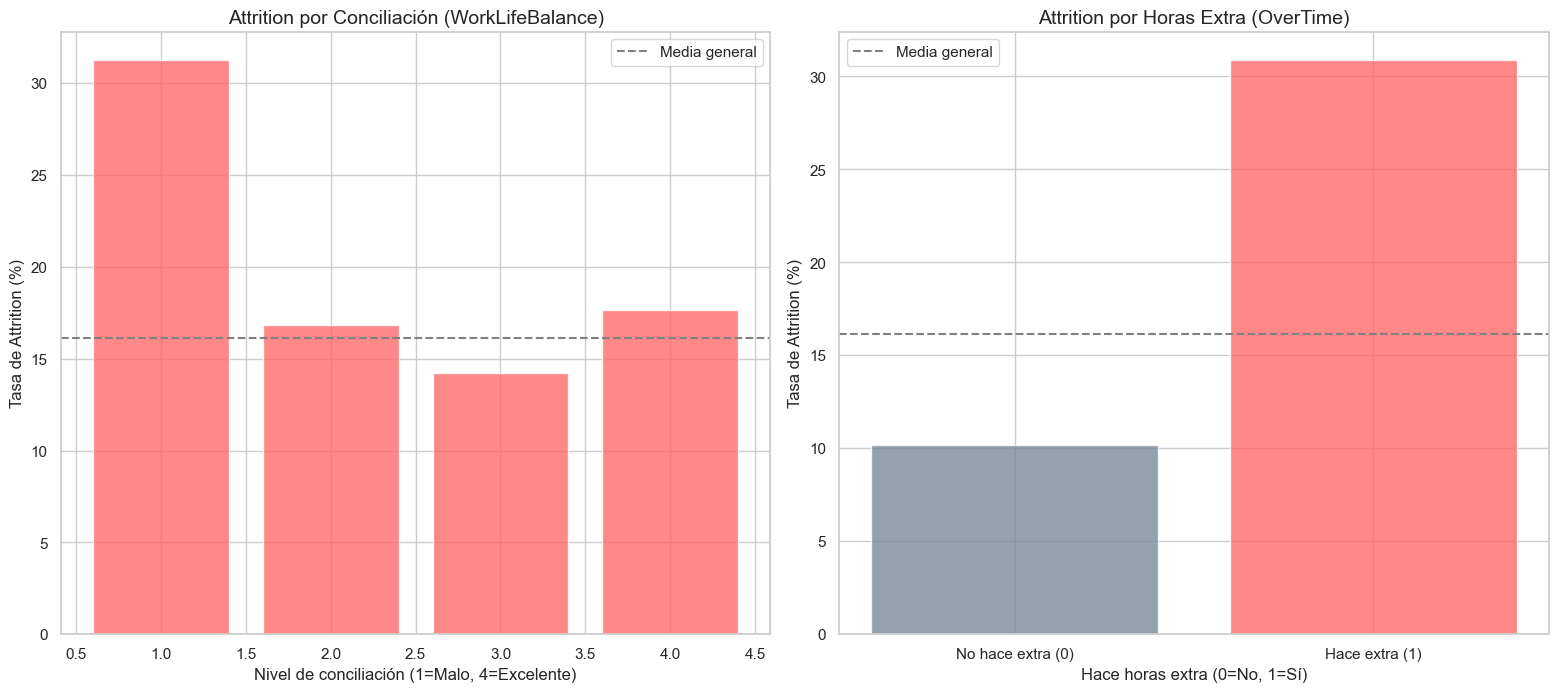

In [26]:
# Definimos el factor de conversión de centímetros a pulgadas
cm = 1 / 2.54

# Creamos un lienzo con DOS gráficos lado a lado (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40*cm, 18*cm))

# ---- GRÁFICO 1: WorkLifeBalance vs Attrition ----

# Calculamos la tasa de attrition por nivel de conciliación
# WorkLifeBalance va de 1 (malo) a 4 (excelente)
attrition_wlb = df_eda.groupby('WorkLifeBalance')['Attrition'].mean() * 100

# Dibujamos las barras con el color rojo de la paleta
ax1.bar(attrition_wlb.index, attrition_wlb.values, color=PALETA_FUGA[1], alpha=0.8)

# Añadimos la línea de media general para comparar
ax1.axhline(y=df_eda['Attrition'].mean() * 100, color='gray',
            linestyle='--', linewidth=1.5, label='Media general')

# Ponemos título y etiquetas
ax1.set_title('Attrition por Conciliación (WorkLifeBalance)')
ax1.set_xlabel('Nivel de conciliación (1=Malo, 4=Excelente)')
ax1.set_ylabel('Tasa de Attrition (%)')
ax1.legend()

# ---- GRÁFICO 2: OverTime vs Attrition ----

# Eliminamos los nulos de OverTime para este gráfico
df_overtime = df_eda.dropna(subset=['OverTime'])

# Calculamos la tasa de attrition por si hace horas extra (0=No, 1=Sí)
attrition_ot = df_overtime.groupby('OverTime')['Attrition'].mean() * 100

# Dibujamos las barras con colores de la paleta: gris=no hace extra, rojo=sí hace extra
ax2.bar(attrition_ot.index, attrition_ot.values,
        color=[PALETA_FUGA[0], PALETA_FUGA[1]], alpha=0.8)

# Añadimos la línea de media general
ax2.axhline(y=df_eda['Attrition'].mean() * 100, color='gray',
            linestyle='--', linewidth=1.5, label='Media general')

# Ponemos título y etiquetas
ax2.set_title('Attrition por Horas Extra (OverTime)')
ax2.set_xlabel('Hace horas extra (0=No, 1=Sí)')
ax2.set_ylabel('Tasa de Attrition (%)')

# Ponemos etiquetas en el eje X más claras
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['No hace extra (0)', 'Hace extra (1)'])
ax2.legend()

# Ajustamos el espaciado entre los dos gráficos
plt.tight_layout()

# Mostramos el gráfico
plt.show()

**Conclusión — Conciliación y horas extra vs Attrition**

Los dos gráficos juntos cuentan una historia muy clara sobre el bienestar del empleado:

**Gráfico izquierdo (WorkLifeBalance):**
- El nivel 1 (mala conciliación) dispara la fuga hasta el 31%, casi el doble de la media.
- Los niveles 2 y 3 se sitúan cerca de la media o por debajo.
- El nivel 4 (excelente conciliación) tiene un repunte inesperado, lo que puede indicar que empleados muy cómodos reciben y aceptan ofertas externas atractivas.

**Gráfico derecho (OverTime):**
- Los empleados que NO hacen horas extra tienen una tasa de fuga del 10%, muy por debajo de la media.
- Los que SÍ hacen horas extra se van en un 31%, triplicando la tasa de los que no las hacen.

**Recomendación:** Las horas extra son el factor de desgaste más directo y medible. Reducirlas o compensarlas correctamente tendría un impacto inmediato y muy significativo en la retención de talento.

## Pregunta 5 — ¿Qué hace que un empleado esté cómodo?
### Heatmap de correlaciones numéricas

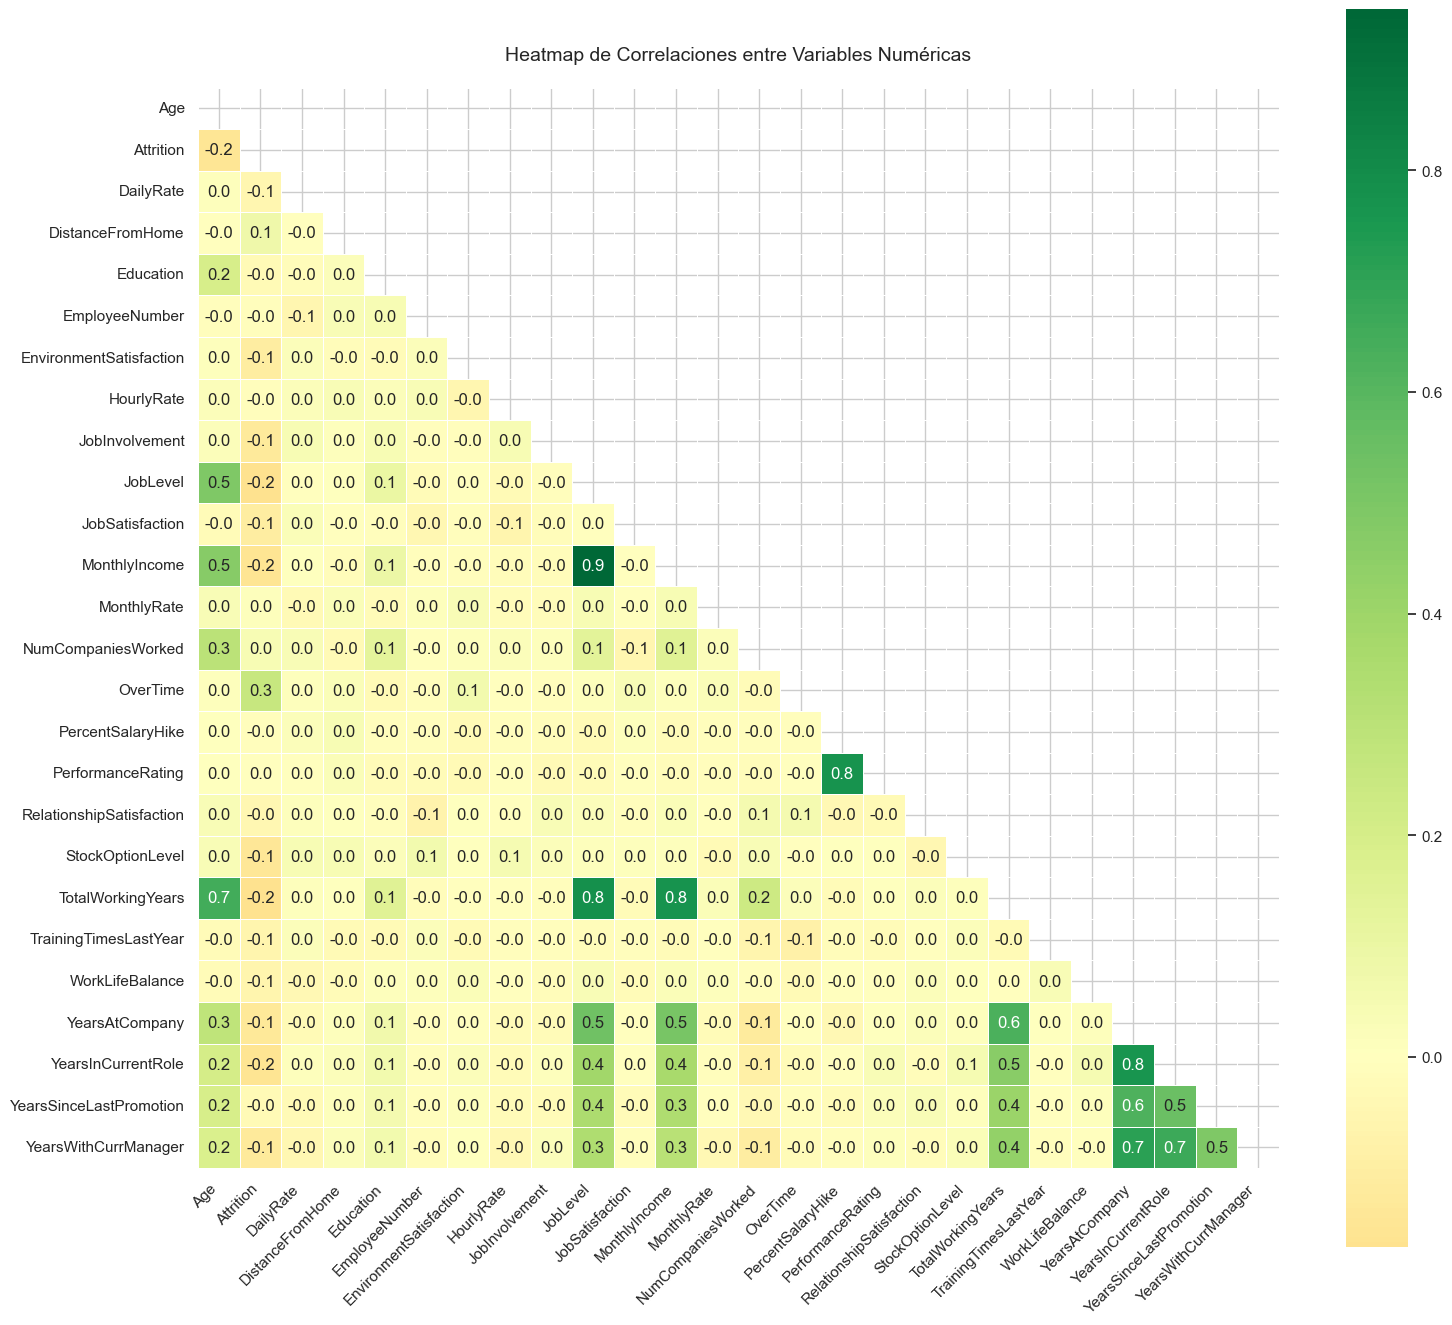

In [27]:
# Definimos el factor de conversión de centímetros a pulgadas
cm = 1 / 2.54

# Creamos el lienzo, más grande porque el heatmap tiene muchas variables
fig, ax = plt.subplots(figsize=(40*cm, 35*cm))

# Seleccionamos solo las columnas numéricas del dataframe
# ya que el heatmap solo funciona con números
df_numericas = df_eda.select_dtypes(include='number')

# Calculamos la matriz de correlación entre todas las columnas numéricas
# La correlación va de -1 (correlación negativa perfecta) a 1 (correlación positiva perfecta)
# Un valor cercano a 0 significa que no hay relación entre las variables
correlaciones = df_numericas.corr()

# Creamos una máscara para ocultar el triángulo superior del heatmap
# ya que es simétrico y mostrar los dos lados es redundante
import numpy as np
mascara = np.triu(np.ones_like(correlaciones, dtype=bool))

# Dibujamos el heatmap con la máscara aplicada
sns.heatmap(
    correlaciones,          # La matriz de correlaciones
    mask=mascara,           # Ocultamos el triángulo superior
    annot=True,             # Mostramos los valores numéricos dentro de cada celda
    fmt='.1f',              # Formato con 1 decimal para que no ocupe demasiado
    cmap='RdYlGn',          # Paleta de colores: rojo=negativo, amarillo=neutro, verde=positivo
    center=0,               # El centro de la paleta es el 0
    square=True,            # Celdas cuadradas para mejor lectura
    linewidths=0.5,         # Líneas finas entre celdas
    ax=ax                   # Usamos el eje que creamos antes
)

# Ponemos título y ajustamos las etiquetas del eje X
ax.set_title('Heatmap de Correlaciones entre Variables Numéricas', pad=20)
plt.xticks(rotation=45, ha='right')  # Rotamos etiquetas eje X para que sean legibles
plt.yticks(rotation=0)               # Etiquetas eje Y horizontales

# Ajustamos el espaciado
plt.tight_layout()

# Mostramos el gráfico
plt.show()

**Conclusión — Heatmap de correlaciones numéricas**

El heatmap nos permite ver de un vistazo qué variables están relacionadas entre sí:

**Correlaciones más fuertes detectadas:**
- **`MonthlyIncome` y `JobLevel` (0.9):** Casi perfecta. El nivel de puesto determina directamente el salario, lo cual es lógico.
- **`TotalWorkingYears` y `MonthlyIncome` (0.8):** A más años trabajados, mayor salario.
- **`TotalWorkingYears` y `JobLevel` (0.8):** A más experiencia, mayor nivel de puesto.
- **`YearsInCurrentRole` y `YearsWithCurrManager` (0.7):** Los empleados tienden a cambiar de manager cuando cambian de rol.

**Relación con Attrition:**
- **`Attrition` y `Age` (-0.2):** Correlación negativa débil. Los empleados más jóvenes tienen ligeramente más tendencia a irse.
- **`Attrition` y `MonthlyIncome` (-0.2):** A menor salario, mayor probabilidad de fuga.
- **`Attrition` y `JobLevel` (-0.2):** A menor nivel de puesto, mayor fuga.

**Conclusión general:** Ninguna variable por sí sola explica completamente la fuga, lo que confirma que la retención es un fenómeno multifactorial que hay que abordar desde varios frentes a la vez.

##  Conclusiones Finales y Recomendaciones de Negocio

###  1. Resumen del Proceso de Calidad de Datos (Gobernanza y ETL)
Para garantizar la fiabilidad de este análisis, los datos pasaron por un riguroso pipeline **ETL (Extract, Transform, Load)**:
* **Extracción:** Carga de los registros crudos de los empleados de ABC Corporation.
* **Transformación:** Limpieza de registros duplicados, tratamiento estructurado de valores ausentes (nulos), corrección de erratas y homogeneización de tipos de datos.
* **Carga:** Consolidación de un tablón analítico limpio y optimizado para la exploración de negocio.

---

### 💡 2. Hallazgos Clave de Negocio (Insights)
Tras cruzar las variables críticas contra la fuga de talento (`Attrition`), se ha determinado el **perfil de riesgo** del empleado en la compañía:

1. **Factor Edad (`Age`):** Los empleados más jóvenes, entre 20 y 35 años, concentran la mayor tasa de fuga. A partir de los 40 años el riesgo se reduce considerablemente.
2. **Factor Antigüedad (`YearsAtCompany`):** Los dos primeros años son los más críticos, con una tasa de fuga superior al 35%. Quien supera ese umbral tiende a quedarse.
3. **Factor Nivel de Puesto (`JobLevel`):** Los empleados de nivel 1 (Junior) presentan una tasa de fuga del 26%, casi el doble de la media. A mayor nivel, mayor retención.
4. **Impacto Económico (`MonthlyIncome`):** Existe una brecha salarial evidente. La mediana de ingresos de los empleados que se van se sitúa en torno a los **$3.500**, notablemente inferior a los **$5.000** de los que se quedan.
5. **Factor Logístico (`DistanceFromHome`):** La distancia al trabajo actúa como desgaste acumulativo. El 75% de los retenidos vive a menos de 13 km, mientras que en el grupo que se fuga la distribución se estira hasta los 17 km o más.
6. **Desgaste por Sobrecarga (`OverTime`):** Las horas extra son el detonante más directo. Los empleados que las realizan tienen una tasa de fuga del 31%, triplicando el 10% de los que no las hacen.
7. **Conciliación (`WorkLifeBalance`):** El nivel 1 de conciliación dispara la fuga hasta el 31%. Una mala conciliación es tan peligrosa como las horas extra.

---

### 🚀 3. Recomendaciones Estratégicas para Recursos Humanos (Plan de Acción)
Para mitigar la fuga de talento en ABC Corporation de forma inmediata, se proponen las siguientes acciones basadas en datos:
* **Plan de Onboarding y Retención Temprana:** Diseñar planes de carrera claros y mentoring específico para los primeros 2 años y para empleados de nivel Junior, que es donde se concentra el mayor riesgo.
* **Política de Compensación y Techo de Horas Extra:** Limitar las horas extra o asegurar una compensación superior para evitar el *burnout*. Es la medida con mayor impacto inmediato.
* **Auditoría Salarial:** Revisar el suelo salarial de las posiciones operativas para aproximar la mediana de ingresos hacia los **$4.500 - $5.000** en posiciones estratégicas de retención.
* **Flexibilidad Logística y Teletrabajo:** Implementar jornadas híbridas orientadas específicamente a empleados cuya distancia al trabajo supere los **13 km**.
* **Programa de Conciliación:** Reforzar las políticas de conciliación para reducir el número de empleados en nivel 1 de WorkLifeBalance, que es el grupo de mayor riesgo.